# Modulo 3 - Ruido blanco y caminata aleatoria en Python

Curso: **Series Temporales con R y Python** (Frogames Formacion).

Codigo de acompanamiento de la leccion `03-caracteristicas-fundamentales/01-ruido-blanco-y-caminata-aleatoria` -- abrelo mientras lees la leccion y ejecuta cada celda tu mismo.

Partimos del mismo dataset del Modulo 2 (`indices_2015_2026.csv`), simplificado a `market_value` (S&P 500) y cortado a train, para comparar la serie real con dos series simuladas: ruido blanco y una caminata aleatoria.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

df_comp = pd.read_csv("indices_2015_2026.csv", parse_dates=["date"], index_col="date")
df_comp = df_comp.asfreq('B')
df_comp.spx = df_comp.spx.ffill()
df_comp.ftse = df_comp.ftse.bfill()
df_comp.dax = df_comp.dax.fillna(value=df_comp.dax.mean())
df_comp.nikkei = df_comp.nikkei.ffill().bfill()
df_comp['market_value'] = df_comp.spx
df_comp = df_comp[['market_value']]

size = int(len(df_comp) * 0.8)
df = df_comp.iloc[:size].copy()
df_test = df_comp.iloc[size:].copy()
print(df.shape)
df.head()

(2442, 1)


,market_value
date,
2015-01-02,2058.199951
2015-01-05,2020.579956
2015-01-06,2002.609985
2015-01-07,2025.900024
2015-01-08,2062.139893


## Ruido blanco

Una serie de ruido blanco es una secuencia de valores independientes, con media y varianza constantes, sin ninguna estructura temporal que un modelo pueda aprovechar. La generamos con la misma media y desviacion tipica que `market_value`, para que se pueda comparar a simple vista contra la serie real.

In [2]:
wn = np.random.normal(loc=df.market_value.mean(), scale=df.market_value.std(), size=len(df))
df['wn'] = wn
df[['market_value', 'wn']].describe()

,market_value,wn
count,2442.000000,2442.000000
mean,3200.855103,3231.864607
std,931.898283,917.620812
min,1829.079956,180.323635
25%,2387.619934,2616.643784
50%,2924.079956,3226.513523
75%,4089.997437,3831.854019
max,5254.350098,6791.208963


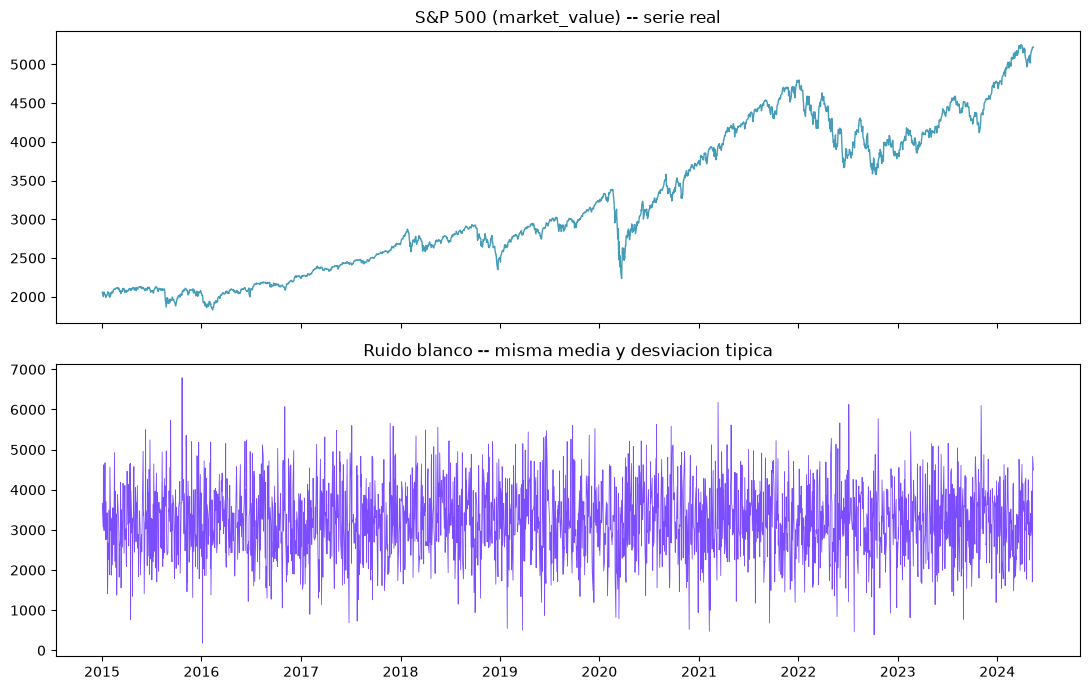

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df.index, df.market_value, color='#449cb9', linewidth=1)
axes[0].set_title('S&P 500 (market_value) -- serie real')
axes[1].plot(df.index, df.wn, color='#7c4dff', linewidth=0.6)
axes[1].set_title('Ruido blanco -- misma media y desviacion tipica')
plt.tight_layout()
plt.savefig('wn_vs_market.png', dpi=130)
plt.show()

## Caminata aleatoria (random walk)

Una caminata aleatoria se construye acumulando pasos aleatorios: `Y_t = Y_{t-1} + e_t`, con `e_t` ruido blanco. A diferencia del ruido blanco, cada valor SI depende del anterior -- pero de una forma muy simple: el mejor pronostico del valor de manana es el valor de hoy.

In [4]:
steps = np.random.normal(loc=0, scale=1, size=len(df))
steps[0] = 0
rw_values = df.market_value.iloc[0] + np.cumsum(steps) * (df.market_value.std() * 0.01)
df['rw'] = rw_values
df[['market_value', 'rw']].describe()

,market_value,rw
count,2442.000000,2442.000000
mean,3200.855103,1977.895845
std,931.898283,236.780186
min,1829.079956,1449.874507
25%,2387.619934,1786.026202
50%,2924.079956,2063.224075
75%,4089.997437,2156.249942
max,5254.350098,2352.615378


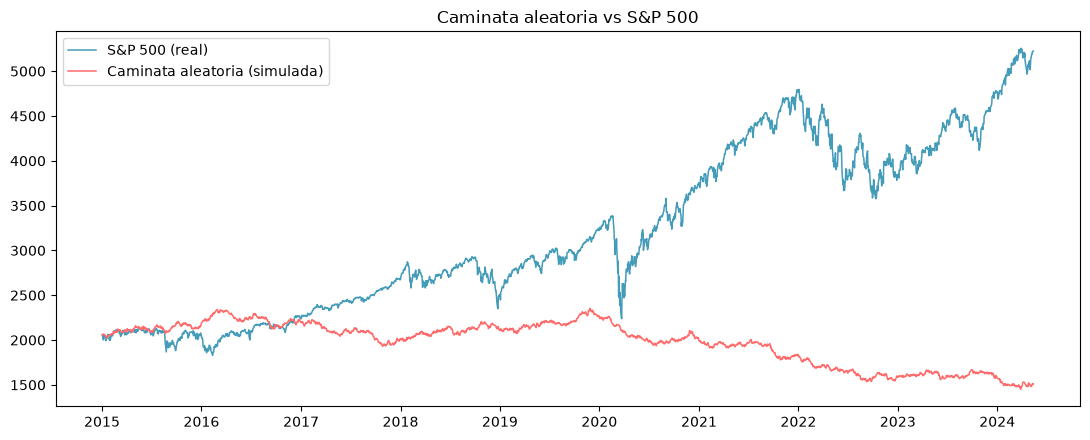

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df.index, df.market_value, label='S&P 500 (real)', color='#449cb9', linewidth=1.1)
ax.plot(df.index, df.rw, label='Caminata aleatoria (simulada)', color='#ff6b6b', linewidth=1.1)
ax.set_title('Caminata aleatoria vs S&P 500')
ax.legend()
plt.tight_layout()
plt.savefig('rw_vs_market.png', dpi=130)
plt.show()

**Entregable**: reproduce estas celdas y cambia la escala del paso de la caminata aleatoria (`* 0.01`) por `* 0.005` y por `* 0.02`. Anota como cambia la "amplitud" visual de la caminata frente al S&P 500 real -- es la misma logica que la volatilidad de un activo real.